In [6]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed


Price             Close     sma_fast     sma_slow sma_signal
Ticker      RELIANCE.NS                                     
Date                                                        
2025-12-17  1544.400024  1542.990002  1533.596676          0
2025-12-18  1544.400024  1543.870007  1535.206677          0
2025-12-19  1565.099976  1546.320007  1538.110010          0
2025-12-22  1575.400024  1549.560010  1540.980009          0
2025-12-23  1570.699951  1553.690002  1543.556673          0
2025-12-24  1558.199951  1555.819995  1545.113338          0
2025-12-25  1558.199951  1557.139990  1546.690002          0
2025-12-26  1559.199951  1557.409985  1548.033333          0
2025-12-29  1545.599976  1556.349988  1548.943331          0
2025-12-30  1539.800049  1556.099988  1549.623332          0


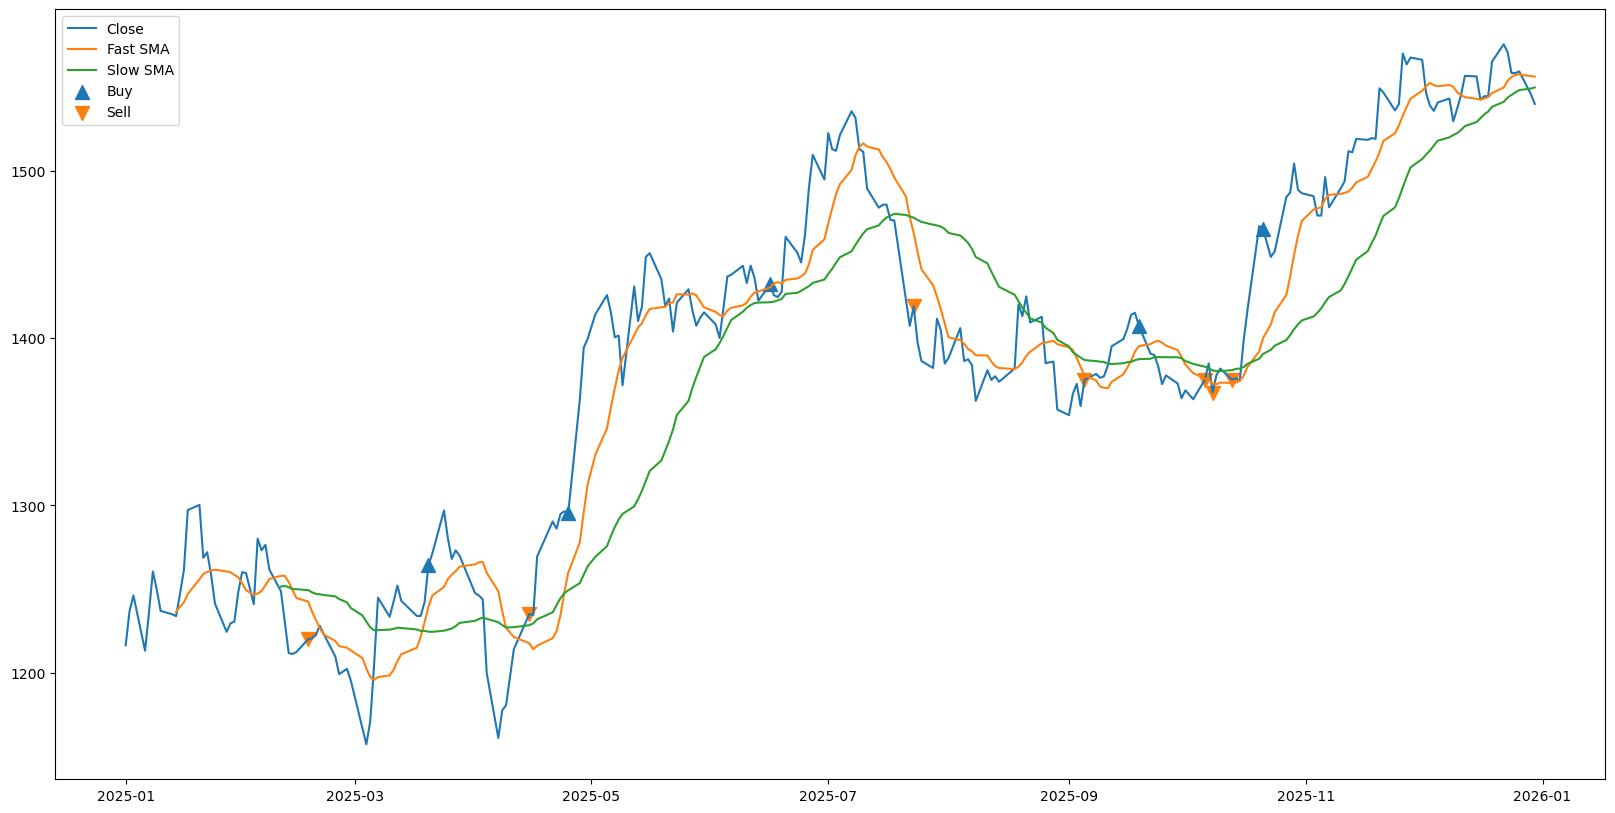

In [10]:
class SMAindicator:
    def __init__(self,data,fast=10,slow=30):
        self.data=data
        self.fast=fast
        self.slow=slow
        
    def calculate_sma(self):
        self.data['sma_fast']= self.data['Close'].rolling(window=self.fast).mean()
        self.data['sma_slow']= self.data['Close'].rolling(window=self.slow).mean()
        return self.data
    
    def sma_signal(self):
        threshold=0.005
        self.data['sma_signal']=0
        self.data['up']= self.data['sma_slow']*(1+threshold)
        self.data['down']= self.data['sma_slow']*(1-threshold)
        self.data.loc[(self.data['sma_fast']>self.data['up'])&(self.data['sma_fast'].shift(1)<=self.data['up'].shift(1)),'sma_signal']=1
        self.data.loc[(self.data['sma_fast']<self.data['down'])&(self.data['sma_fast'].shift(1)>=self.data['down'].shift(1)),'sma_signal']=-1
        return self.data
           

data = yf.download("RELIANCE.NS", start="2025-01-01", end="2025-12-31")
sma= SMAindicator(data,10,30)
data= sma.calculate_sma()
data=sma.sma_signal()
print(data[['Close','sma_fast','sma_slow','sma_signal']].tail(10))

plt.figure(figsize=(20,10))
plt.plot(data['Close'],label='Close')
plt.plot(data['sma_fast'],label='Fast SMA')
plt.plot(data['sma_slow'],label='Slow SMA')

buy=data[data['sma_signal']==1]
sell=data[data['sma_signal']==-1]

plt.scatter(buy.index, buy['Close'], marker='^', s=100, label='Buy')
plt.scatter(sell.index, sell['Close'], marker='v', s=100, label='Sell')
plt.legend()
plt.show()

[*********************100%***********************]  1 of 1 completed


Price             Close     ema_fast     ema_slow ema_signal
Ticker      RELIANCE.NS                                     
Date                                                        
2025-12-17  1544.400024  1544.514621  1531.716389          0
2025-12-18  1544.400024  1544.496991  1532.655918          0
2025-12-19  1565.099976  1547.666681  1535.059181          0
2025-12-22  1575.400024  1551.933349  1538.047392          0
2025-12-23  1570.699951  1554.820519  1540.466100          0
2025-12-24  1558.199951  1555.340431  1541.779719          0
2025-12-25  1558.199951  1555.780357  1542.996032          0
2025-12-26  1559.199951  1556.306449  1544.196323          0
2025-12-29  1545.599976  1554.659299  1544.300297          0
2025-12-30  1539.800049  1552.373261  1543.966945          0


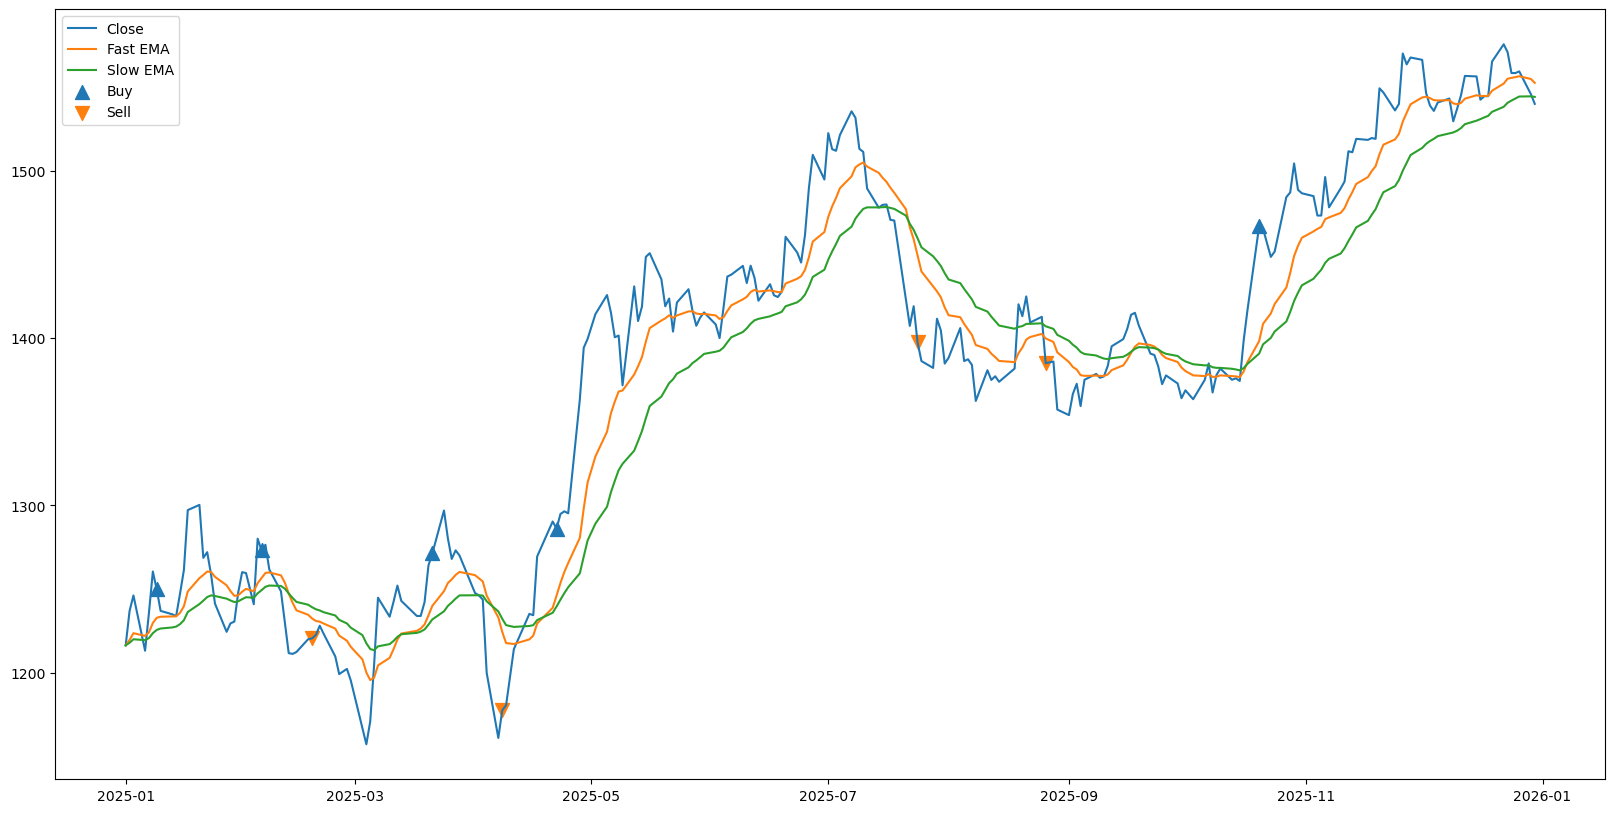

In [11]:
class EMAindicator:
    def __init__(self,data,fast=12,slow=26):
        self.data=data
        self.fast=fast
        self.slow=slow
        
    def calculate_ema(self):
      self.data['ema_fast'] = self.data['Close'].ewm(span=self.fast, adjust=False).mean()
      self.data['ema_slow'] = self.data['Close'].ewm(span=self.slow, adjust=False).mean()
      
      return self.data

    def ema_signal(self):
        threshold=0.005
        self.data['ema_signal']=0
        self.data['up']=self.data['ema_slow']*(1+threshold)
        self.data['down']=self.data['ema_slow']*(1-threshold)
        self.data.loc[(self.data['ema_fast']>self.data['up'])&(self.data['ema_fast'].shift(1)<=self.data['up'].shift(1)),'ema_signal']=1
        self.data.loc[(self.data['ema_fast']<self.data['down'])&(self.data['ema_fast'].shift(1)>=self.data['down'].shift(1)),'ema_signal']=-1
       
        return self.data
    
data = yf.download("RELIANCE.NS", start="2025-01-01", end="2025-12-31")
ema= EMAindicator(data,12,26)
data= ema.calculate_ema()
data=ema.ema_signal()
print(data[['Close','ema_fast','ema_slow','ema_signal']].tail(10))

plt.figure(figsize=(20,10))
plt.plot(data['Close'],label='Close')
plt.plot(data['ema_fast'],label='Fast EMA')
plt.plot(data['ema_slow'],label='Slow EMA')

buy=data[data['ema_signal']==1]
sell=data[data['ema_signal']==-1]

plt.scatter(buy.index, buy['Close'], marker='^', s=100, label='Buy')
plt.scatter(sell.index, sell['Close'], marker='v', s=100, label='Sell')
plt.legend()
plt.show()    